In [1]:
!pip install pandas numpy scikit-learn nltk matplotlib seaborn wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                              f1_score, confusion_matrix, classification_report)

print("All libraries loaded successfully")

All libraries loaded successfully


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vetry\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vetry\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\vetry\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\vetry\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
df = pd.read_csv("phishing_email.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 2 rows:")
df.head(2)

Shape: (82486, 2)

Columns: ['text_combined', 'label']

First 2 rows:


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0


In [4]:
# Check class balance
print("Class distribution:")
print(df['label'].value_counts())
print("\nPercentage:")
print(df['label'].value_counts(normalize=True) * 100)

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check text length stats
df['text_length'] = df['text_combined'].astype(str).apply(len)
print("\nText length stats:")
print(df['text_length'].describe())

Class distribution:
label
1    42891
0    39595
Name: count, dtype: int64

Percentage:
label
1    51.997915
0    48.002085
Name: proportion, dtype: float64

Missing values:
text_combined    0
label            0
dtype: int64

Text length stats:
count    8.248600e+04
mean     1.288751e+03
std      1.549675e+04
min      1.000000e+00
25%      2.760000e+02
50%      5.580000e+02
75%      1.338000e+03
max      4.279526e+06
Name: text_length, dtype: float64


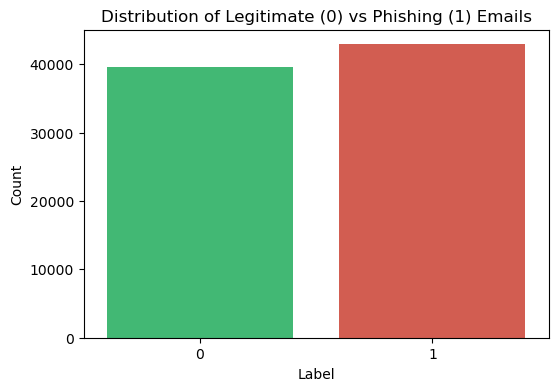

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', hue='label', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Distribution of Legitimate (0) vs Phishing (1) Emails')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [6]:
print("=== LEGITIMATE EMAIL EXAMPLE ===")
print(df[df['label'] == 0]['text_combined'].iloc[0][:500])
print("\n" + "="*60)
print("\n=== PHISHING EMAIL EXAMPLE ===")
print(df[df['label'] == 1]['text_combined'].iloc[0][:500])

=== LEGITIMATE EMAIL EXAMPLE ===
hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls


=== PHISHING EMAIL EXAMPLE ===
link dwl g 510 802 11 g wireless pci lan adapter 39 85 39 85 dwl g 510 high speed 2 4 ghz 802 11 g wireless pci lan adapter ieee 802 11 g standardupto 54 mbpsoperating frequency range 2 4 ghz ideal solution enabling wireless networking capabilities desktops pcs home office dwl g 510 visit http www computron com deals link dwl g 510 802 11 g wireless pci lan adapter link g 510 wireless pci adapter featuring latest ieee 802 11 g wireless technology deliverincredibly fast data transfer 2 4 ghz freq


In [7]:
# Drop the text_length column we made earlier - we'll rebuild it
if 'text_length' in df.columns:
    df = df.drop(columns=['text_length'])

# Convert to string and get length
df['text_combined'] = df['text_combined'].astype(str)
df['text_length'] = df['text_combined'].apply(len)

# Filter: keep emails with reasonable length (between 20 and 20,000 characters)
# This removes junk (too short) and massive outliers (too long)
before = df.shape[0]
df = df[(df['text_length'] >= 20) & (df['text_length'] <= 20000)].reset_index(drop=True)
after = df.shape[0]
print(f"Removed {before - after} outlier rows. New shape: {df.shape}")

# Recheck class balance after filtering
print("\nClass distribution after filtering:")
print(df['label'].value_counts())

Removed 296 outlier rows. New shape: (82190, 3)

Class distribution after filtering:
label
1    42845
0    39345
Name: count, dtype: int64


In [8]:
# Suspicious keywords commonly found in phishing emails
suspicious_words = ['click', 'verify', 'urgent', 'suspend', 'account', 'password', 
                    'login', 'update', 'confirm', 'winner', 'prize', 'free', 
                    'limited', 'expire', 'security', 'alert', 'bank', 'link', 
                    'http', 'www']

def count_suspicious(text):
    text = text.lower()
    return sum(text.count(word) for word in suspicious_words)

df['suspicious_count'] = df['text_combined'].apply(count_suspicious)
df['word_count'] = df['text_combined'].apply(lambda x: len(x.split()))

print(df[['text_length', 'word_count', 'suspicious_count', 'label']].head())
print("\nAverage suspicious word count:")
print(df.groupby('label')['suspicious_count'].mean())

   text_length  word_count  suspicious_count  label
0           65          14                 0      0
1         1071         208                 0      0
2          148          28                 0      0
3           65          14                 0      0
4           65          14                 0      0

Average suspicious word count:
label
0    3.605287
1    6.524799
Name: suspicious_count, dtype: float64


In [9]:
df.to_csv("phishing_email_cleaned.csv", index=False)
print("Cleaned dataset saved as phishing_email_cleaned.csv")

Cleaned dataset saved as phishing_email_cleaned.csv


In [10]:
# Define features (X) and target (y)
X_text = df['text_combined']
y = df['label']

# Train-test split (80% train, 20% test)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train_text.shape[0]} emails")
print(f"Test set: {X_test_text.shape[0]} emails")

# TF-IDF vectorizer - convert text to numeric features
tfidf = TfidfVectorizer(
    max_features=5000,      # keep top 5000 most informative words
    ngram_range=(1, 2),     # use single words + word pairs
    min_df=5,               # word must appear in at least 5 emails
    max_df=0.7              # ignore words appearing in >70% of emails
)

# Fit on training data, transform both
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(f"\nTF-IDF feature matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF feature matrix shape (test): {X_test_tfidf.shape}")

Training set: 65752 emails
Test set: 16438 emails

TF-IDF feature matrix shape (train): (65752, 5000)
TF-IDF feature matrix shape (test): (16438, 5000)


In [11]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("\n=== Logistic Regression Results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate', 'Phishing']))

Training Logistic Regression...

=== Logistic Regression Results ===
Accuracy:  0.9825
Precision: 0.9807
Recall:    0.9858
F1 Score:  0.9832

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.98      0.98      7869
    Phishing       0.98      0.99      0.98      8569

    accuracy                           0.98     16438
   macro avg       0.98      0.98      0.98     16438
weighted avg       0.98      0.98      0.98     16438



In [12]:
print("Training Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("\n=== Naive Bayes Results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_nb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Legitimate', 'Phishing']))

Training Naive Bayes...

=== Naive Bayes Results ===
Accuracy:  0.9536
Precision: 0.9845
Recall:    0.9257
F1 Score:  0.9542

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.92      0.98      0.95      7869
    Phishing       0.98      0.93      0.95      8569

    accuracy                           0.95     16438
   macro avg       0.95      0.95      0.95     16438
weighted avg       0.96      0.95      0.95     16438



In [13]:
print("Training Random Forest... this takes 2-3 minutes, be patient")
rf_model = RandomForestClassifier(
    n_estimators=100,       # 100 trees
    max_depth=50,           # limit depth to prevent overfitting + save memory
    n_jobs=-1,              # use all CPU cores
    random_state=42
)
rf_model.fit(X_train_tfidf, y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)

print("\n=== Random Forest Results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Legitimate', 'Phishing']))

Training Random Forest... this takes 2-3 minutes, be patient

=== Random Forest Results ===
Accuracy:  0.9807
Precision: 0.9739
Recall:    0.9894
F1 Score:  0.9816

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.97      0.98      7869
    Phishing       0.97      0.99      0.98      8569

    accuracy                           0.98     16438
   macro avg       0.98      0.98      0.98     16438
weighted avg       0.98      0.98      0.98     16438



In [14]:
print("Training Neural Network... this takes 3-5 minutes")
nn_model = MLPClassifier(
    hidden_layer_sizes=(64,),   # one hidden layer with 64 neurons
    max_iter=30,                # limit iterations to keep it fast
    random_state=42,
    early_stopping=True,        # stop if not improving
    verbose=False
)
nn_model.fit(X_train_tfidf, y_train)

y_pred_nn = nn_model.predict(X_test_tfidf)

print("\n=== Neural Network Results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nn):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_nn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn, target_names=['Legitimate', 'Phishing']))

Training Neural Network... this takes 3-5 minutes

=== Neural Network Results ===
Accuracy:  0.9844
Precision: 0.9864
Recall:    0.9837
F1 Score:  0.9850

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.98      7869
    Phishing       0.99      0.98      0.99      8569

    accuracy                           0.98     16438
   macro avg       0.98      0.98      0.98     16438
weighted avg       0.98      0.98      0.98     16438



In [15]:
# Collect all results into a DataFrame
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Random Forest', 'Neural Network'],
    'Accuracy':  [accuracy_score(y_test, y_pred_lr),
                  accuracy_score(y_test, y_pred_nb),
                  accuracy_score(y_test, y_pred_rf),
                  accuracy_score(y_test, y_pred_nn)],
    'Precision': [precision_score(y_test, y_pred_lr),
                  precision_score(y_test, y_pred_nb),
                  precision_score(y_test, y_pred_rf),
                  precision_score(y_test, y_pred_nn)],
    'Recall':    [recall_score(y_test, y_pred_lr),
                  recall_score(y_test, y_pred_nb),
                  recall_score(y_test, y_pred_rf),
                  recall_score(y_test, y_pred_nn)],
    'F1 Score':  [f1_score(y_test, y_pred_lr),
                  f1_score(y_test, y_pred_nb),
                  f1_score(y_test, y_pred_rf),
                  f1_score(y_test, y_pred_nn)]
})

results = results.round(4)
print("=== Model Comparison ===")
print(results.to_string(index=False))

# Save results as CSV for your report
results.to_csv("model_comparison_results.csv", index=False)
print("\nResults saved to model_comparison_results.csv")

=== Model Comparison ===
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.9825     0.9807  0.9858    0.9832
        Naive Bayes    0.9536     0.9845  0.9257    0.9542
      Random Forest    0.9807     0.9739  0.9894    0.9816
     Neural Network    0.9844     0.9864  0.9837    0.9850

Results saved to model_comparison_results.csv


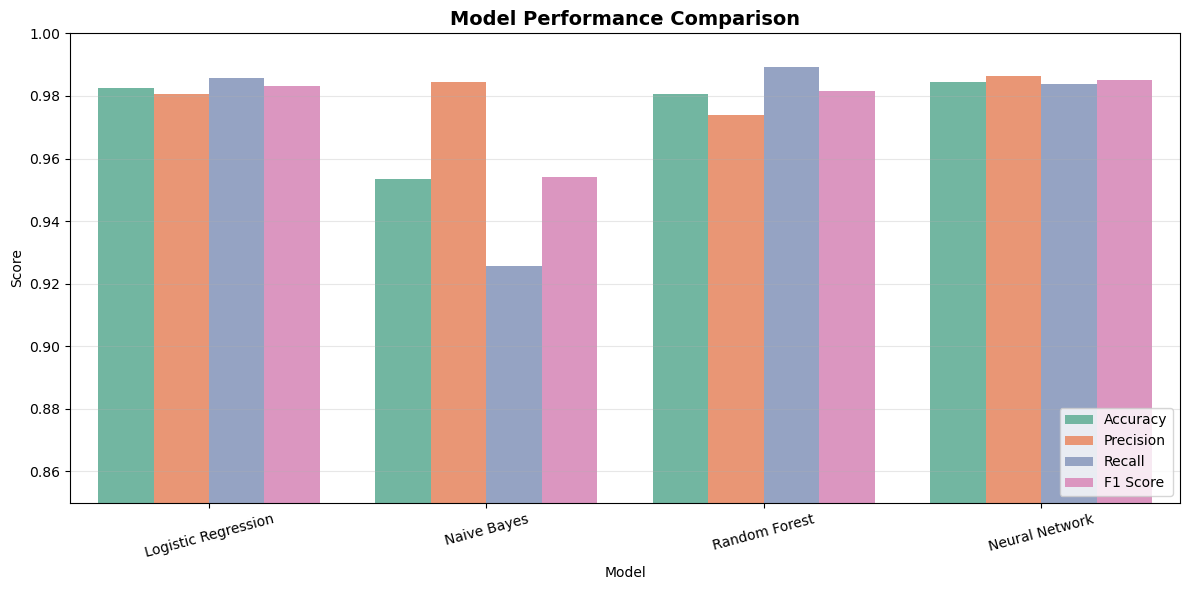

In [16]:
# Bar chart comparing all models on all metrics
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', palette='Set2')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylim(0.85, 1.0)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

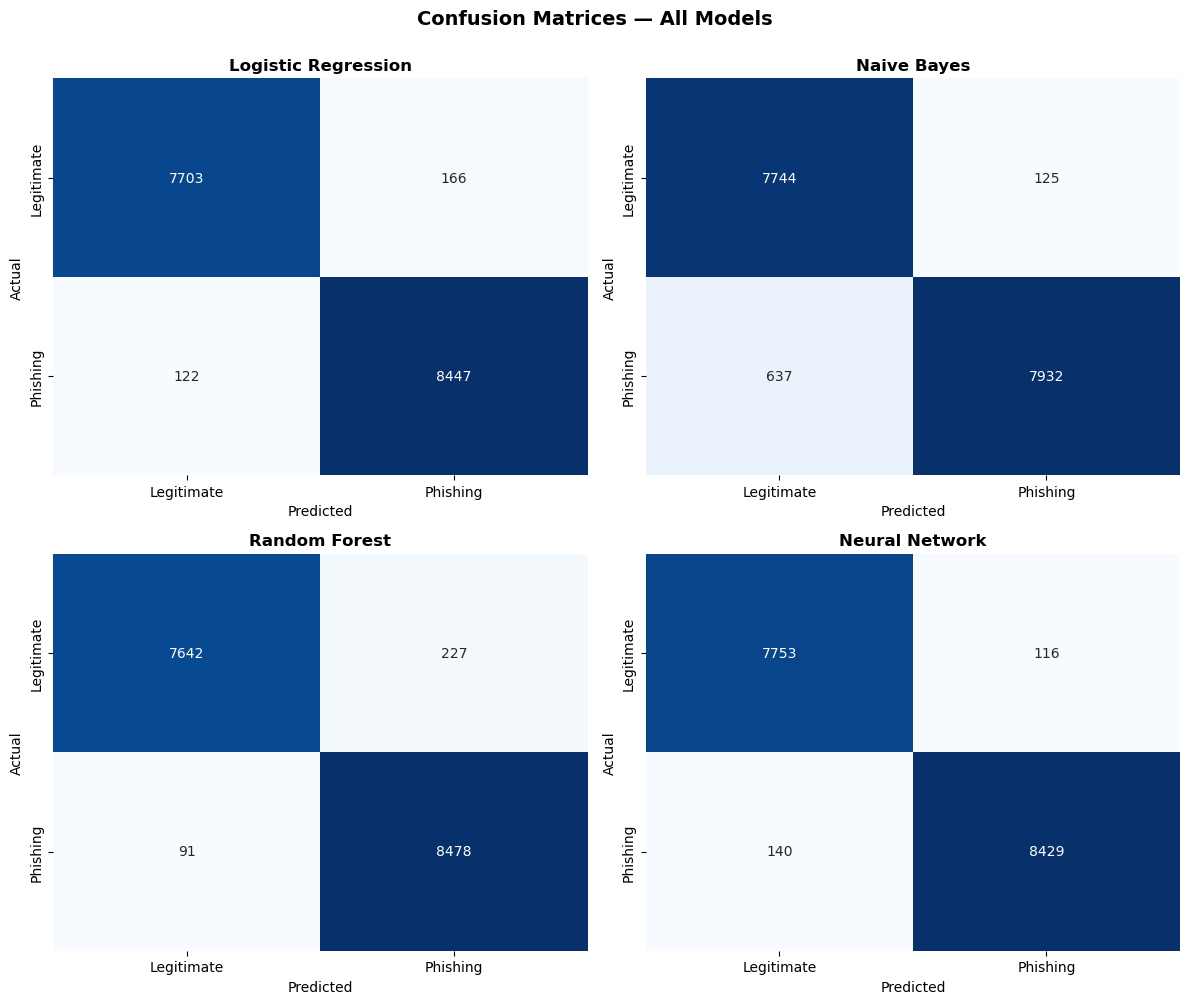

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models_preds = [
    ('Logistic Regression', y_pred_lr),
    ('Naive Bayes', y_pred_nb),
    ('Random Forest', y_pred_rf),
    ('Neural Network', y_pred_nn)
]

for ax, (name, y_pred) in zip(axes.flatten(), models_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate', 'Phishing'],
                yticklabels=['Legitimate', 'Phishing'],
                cbar=False)
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

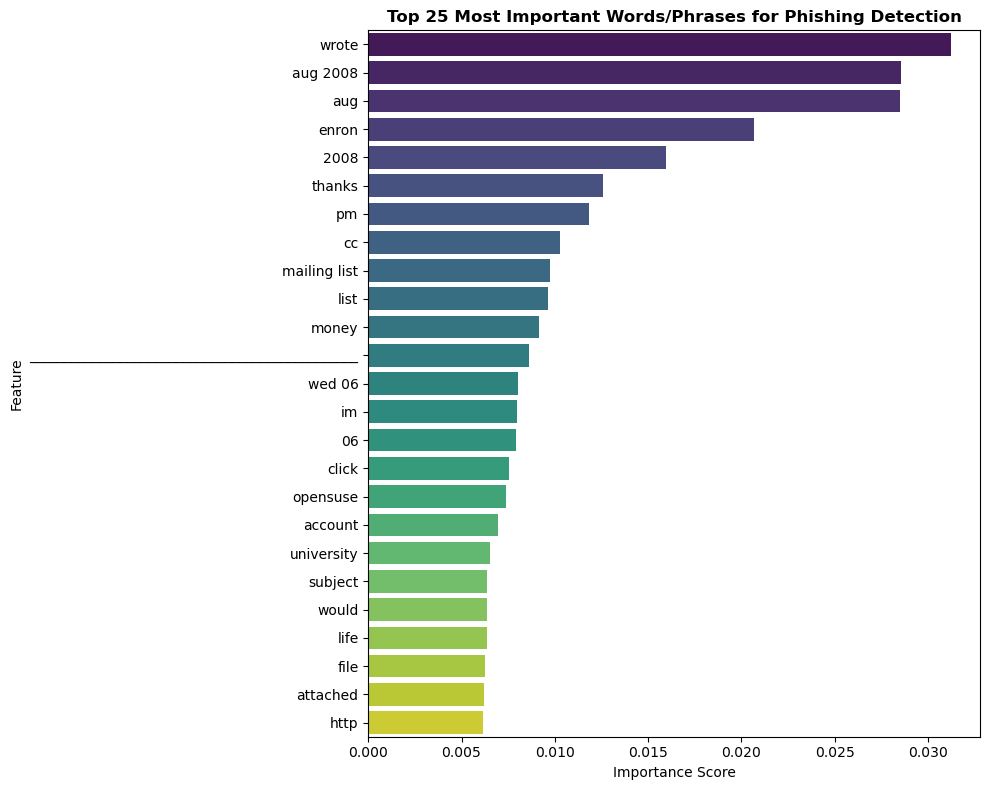


Top 25 phishing indicators:
                                        Feature  Importance
                                          wrote    0.031231
                                       aug 2008    0.028538
                                            aug    0.028505
                                          enron    0.020674
                                           2008    0.015980
                                         thanks    0.012594
                                             pm    0.011848
                                             cc    0.010267
                                   mailing list    0.009721
                                           list    0.009651
                                          money    0.009135
_______________________________________________    0.008603
                                         wed 06    0.008040
                                             im    0.007990
                                             06    0.007915
           

In [18]:
# Get feature importance from Random Forest
feature_names = tfidf.get_feature_names_out()
importances = rf_model.feature_importances_

# Top 25 most important features
top_n = 25
top_indices = importances.argsort()[-top_n:][::-1]
top_features = pd.DataFrame({
    'Feature': feature_names[top_indices],
    'Importance': importances[top_indices]
})

plt.figure(figsize=(10, 8))
sns.barplot(data=top_features, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 25 Most Important Words/Phrases for Phishing Detection', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 25 phishing indicators:")
print(top_features.to_string(index=False))